In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearnex import patch_sklearn
import os
import scipy.ndimage as ndimage
import skimage
import itertools
from tqdm import tqdm
import glob
from skimage.io import imread
import scanpy as sc
import scipy.ndimage as ndi
import multiprocessing
from scipy.ndimage import distance_transform_edt
from scipy.spatial.distance import cdist
from skimage.measure import regionprops,regionprops_table

In [2]:
reload =True
file_name = '../../phenotyping/pixie/data/sc_protein_contrast_adj.h5ad'
if reload:
    adata = sc.read_h5ad(file_name)
else:
    adata = generate_anndata_from_ark_analysis(cell_table_path='../../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv',biosamples_path='../../IMC_preprocessing/processed_files/processed_response.csv')



In [3]:
adata_carbo = adata[(adata.obs['SAMPLE_TYPE']=='RESECTION')&(adata.obs['NACT_treatment _group'] == 'EC-T-carbo')].copy()
adata_nocarbo = adata[(adata.obs['SAMPLE_TYPE']=='RESECTION')&(adata.obs['NACT_treatment _group'] == 'EC-T')].copy()

<Axes: >

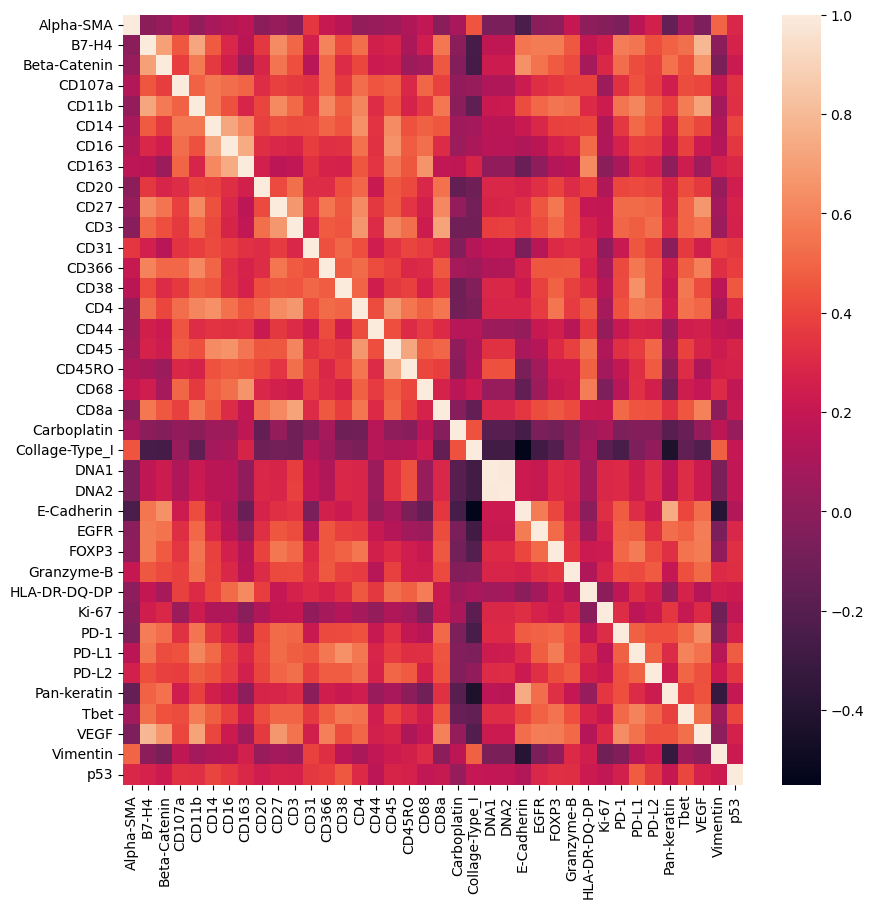

In [8]:
corr = pd.DataFrame(np.corrcoef(adata_carbo.X,rowvar=False),index = adata_carbo.var.index,columns=adata_carbo.var.index)
plt.figure(figsize = (10,10))
sns.heatmap(corr)


In [9]:
markers_2_consider = ['Alpha-SMA','Vimentin','Beta-Catenin','E-Cadherin','Carboplatin','Collage-Type_I']


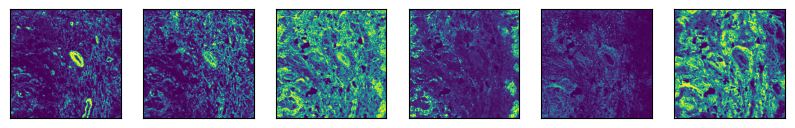

In [13]:
f,axs = plt.subplots(ncols  =len(markers_2_consider),figsize =(10,3))
for i,name in enumerate(markers_2_consider):
    axs[i].imshow(skimage.io.imread('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/contrast_adj/Leap081_7/'+name+'.tiff'))
#axs[i+1].imshow(skimage.io.imread('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/contrast_adj/Leap002_7/Carboplatin.tiff'))
#
#for ax in itertools.chain.from_iterable(axs):
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

['Leap002_1', 'Leap002_3', 'Leap002_4', 'Leap002_5', 'Leap002_6', ..., 'Leap081_5', 'Leap081_6', 'Leap081_7', 'Leap081_8', 'Leap081_9']
Length: 57
Categories (57, object): ['Leap002_1', 'Leap002_3', 'Leap002_4', 'Leap002_5', ..., 'Leap081_9', 'Leap081_10', 'Leap081_11', 'Leap081_12']

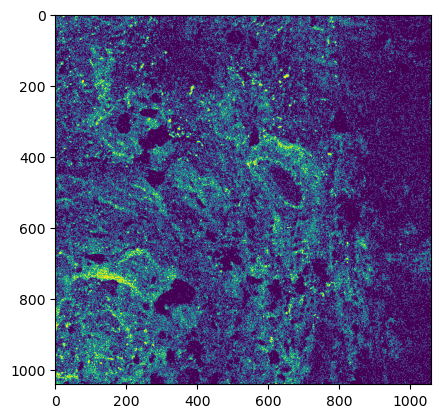

In [54]:
plt.imshow(np.tanh(100*skimage.io.imread('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/contrast_adj/Leap081_7//Carboplatin.tiff')))
adata_carbo.obs.acquisition_ID.unique()

In [11]:
A = pd.DataFrame(adata_carbo[::3,[adata_carbo.var.index.get_loc(marker) for marker in markers_2_consider]].X,columns =markers_2_consider)

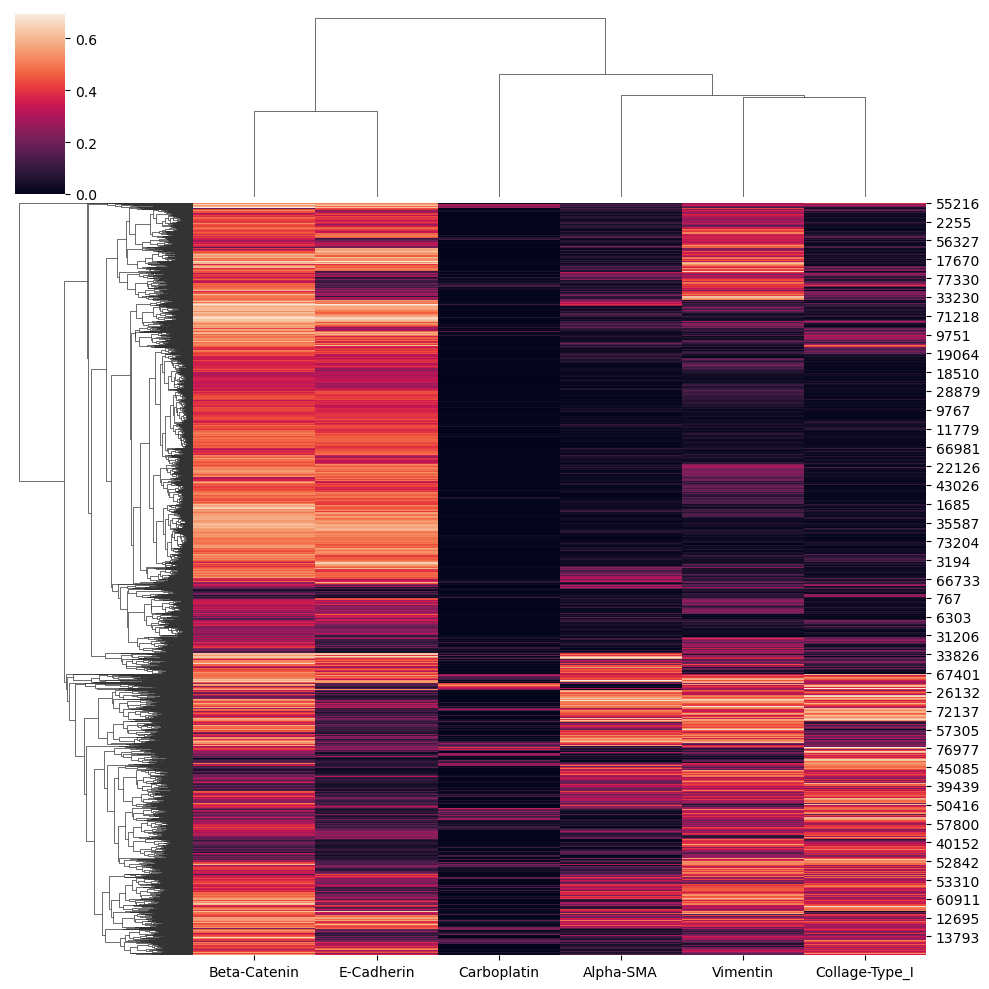

In [12]:
sns.clustermap(A)

In [15]:
markers_2_consider = ['Alpha-SMA','Vimentin','Beta-Catenin','E-Cadherin','Collage-Type_I','p53','Ki-67']
adata_filt = sc.AnnData(X = adata_carbo.X,obs = adata_carbo.obs,var = adata_carbo.var)[::3].copy()
sc.tl.pca(adata_filt,n_comps=10)
sc.pp.neighbors(adata_filt)
sc.tl.umap(adata_filt)

2024-09-10 10:32:02.029580: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-10 10:32:02.041232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-10 10:32:02.056365: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-10 10:32:02.056399: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-10 10:32:02.066068: I tensorflow/core/platform/cpu_feature_gua

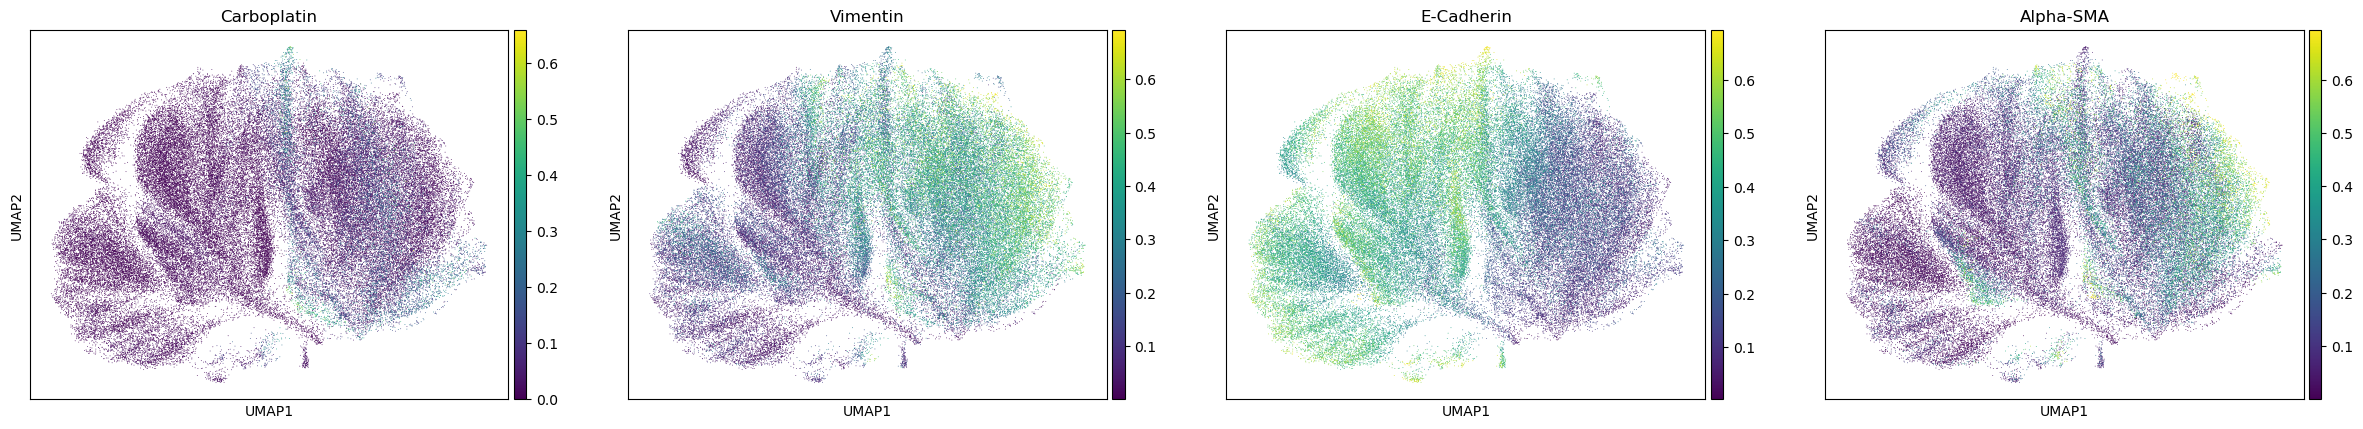

In [17]:
sc.pl.umap(adata_filt,color = ['Carboplatin','Vimentin','E-Cadherin','Alpha-SMA'])